<a href="https://www.kaggle.com/code/sonawanelalitsunil/personal-finance-dataset-for-ml-83-33?scriptVersionId=254077493" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/personal-finance-ml-dataset/synthetic_personal_finance_dataset.csv


## Title:
Personal Finance Dataset for ML



## Description:
This dataset contains anonymized personal financial data that can be used for machine learning tasks like budget forecasting, expense classification, savings prediction, and financial behavior analysis. It includes user demographic information such as age, income, and employment status, along with detailed financial metrics like monthly expenses, savings, debts, investments, credit score, and transaction records.

Each row represents a user or transaction snapshot, enabling both user-level modeling (e.g., predict credit score or savings) and transaction-level modeling (e.g., classify spending category or detect fraud).



## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/personal-finance-ml-dataset/synthetic_personal_finance_dataset.csv")

In [3]:
df.head()

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07


In [4]:
df.tail()

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
32419,U32420,30,Female,High School,Employed,Salesperson,4266.87,1510.82,273669.70,Yes,Car,498400.74,120,6227.54,8.68,1.46,434,5.34,Europe,2024-02-25
32420,U32421,51,Female,Master,Employed,Student,5725.78,4965.02,17247.57,Yes,Home,83602.57,12,7605.13,16.50,1.33,453,0.25,North America,2025-06-06
32421,U32422,18,Female,Bachelor,Self-employed,Doctor,3282.38,2243.77,22081.21,No,NaN,0.00,0,0.00,0.00,0.00,391,0.56,Other,2025-07-20
32422,U32423,36,Other,High School,Self-employed,Accountant,5035.99,4054.32,524039.88,No,NaN,0.00,0,0.00,0.00,0.00,596,8.67,Asia,2022-06-07
32423,U32424,39,Female,Master,Employed,Engineer,4410.19,2866.47,176985.54,No,NaN,0.00,0,0.00,0.00,0.00,689,3.34,North America,2023-08-01


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  32424 non-null  object 
 1   age                      32424 non-null  int64  
 2   gender                   32424 non-null  object 
 3   education_level          32424 non-null  object 
 4   employment_status        32424 non-null  object 
 5   job_title                32424 non-null  object 
 6   monthly_income_usd       32424 non-null  float64
 7   monthly_expenses_usd     32424 non-null  float64
 8   savings_usd              32424 non-null  float64
 9   has_loan                 32424 non-null  object 
 10  loan_type                12995 non-null  object 
 11  loan_amount_usd          32424 non-null  float64
 12  loan_term_months         32424 non-null  int64  
 13  monthly_emi_usd          32424 non-null  float64
 14  loan_interest_rate_pct

In [6]:
df.describe()

,age,monthly_income_usd,monthly_expenses_usd,savings_usd,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio
count,32424.000000,32424.000000,32424.000000,3.242400e+04,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000
mean,43.415865,4027.863185,2419.444709,2.437520e+05,100114.735992,58.500000,3092.992339,6.616332,1.194881,575.260424,5.045431
std,14.978246,1916.773353,1388.893084,1.915772e+05,152536.588635,104.865373,6478.939776,9.472964,3.761964,159.023227,2.851344
min,18.000000,500.000000,150.010000,6.359600e+02,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,0.100000
25%,30.000000,2657.795000,1397.497500,8.629155e+04,0.000000,0.000000,0.000000,0.000000,0.000000,437.000000,2.580000
50%,43.000000,3997.740000,2219.575000,2.017003e+05,0.000000,0.000000,0.000000,0.000000,0.000000,575.000000,5.040000
75%,56.000000,5351.607500,3254.037500,3.589662e+05,189499.070000,60.000000,3574.567500,13.140000,0.920000,714.000000,7.510000
max,69.000000,12404.050000,10082.710000,1.237774e+06,499954.750000,360.000000,47723.840000,30.000000,90.670000,850.000000,10.000000


In [7]:
df.dtypes

user_id                     object
age                          int64
gender                      object
education_level             object
employment_status           object
job_title                   object
monthly_income_usd         float64
monthly_expenses_usd       float64
savings_usd                float64
has_loan                    object
loan_type                   object
loan_amount_usd            float64
loan_term_months             int64
monthly_emi_usd            float64
loan_interest_rate_pct     float64
debt_to_income_ratio       float64
credit_score                 int64
savings_to_income_ratio    float64
region                      object
record_date                 object
dtype: object

In [8]:
df.shape

(32424, 20)

In [9]:
df.isnull().sum()

user_id                        0
age                            0
gender                         0
education_level                0
employment_status              0
job_title                      0
monthly_income_usd             0
monthly_expenses_usd           0
savings_usd                    0
has_loan                       0
loan_type                  19429
loan_amount_usd                0
loan_term_months               0
monthly_emi_usd                0
loan_interest_rate_pct         0
debt_to_income_ratio           0
credit_score                   0
savings_to_income_ratio        0
region                         0
record_date                    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['user_id', 'age', 'gender', 'education_level', 'employment_status',
       'job_title', 'monthly_income_usd', 'monthly_expenses_usd',
       'savings_usd', 'has_loan', 'loan_type', 'loan_amount_usd',
       'loan_term_months', 'monthly_emi_usd', 'loan_interest_rate_pct',
       'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio',
       'region', 'record_date'],
      dtype='object')

## Data visualizations

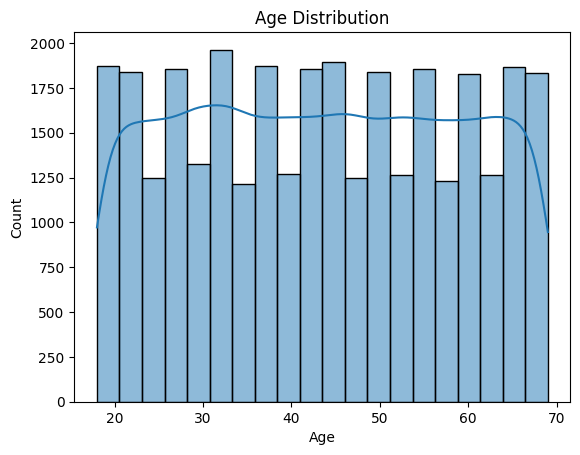

In [12]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


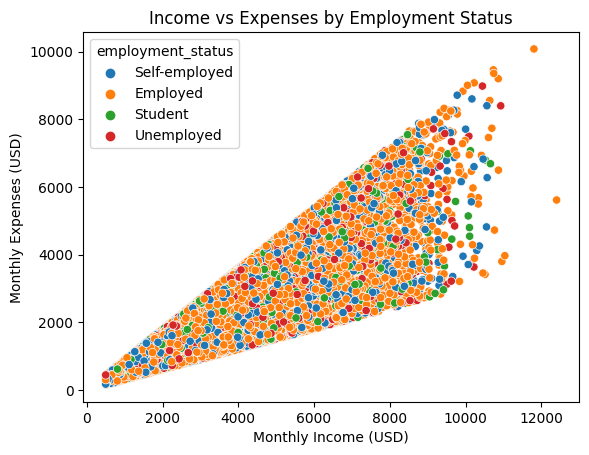

In [13]:
sns.scatterplot(data=df, x='monthly_income_usd', y='monthly_expenses_usd', hue='employment_status')
plt.title('Income vs Expenses by Employment Status')
plt.xlabel('Monthly Income (USD)')
plt.ylabel('Monthly Expenses (USD)')
plt.show()


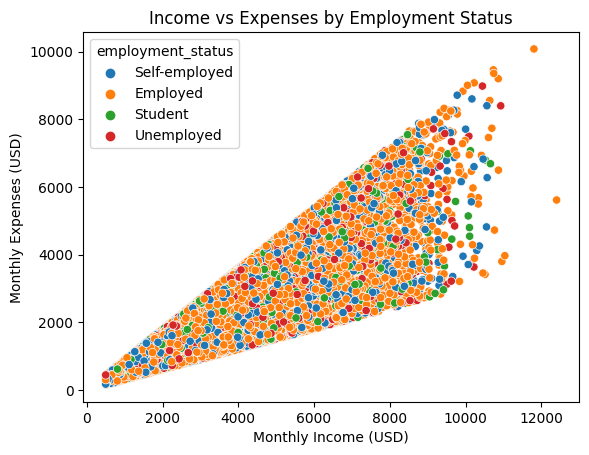

In [14]:
sns.scatterplot(data=df, x='monthly_income_usd', y='monthly_expenses_usd', hue='employment_status')
plt.title('Income vs Expenses by Employment Status')
plt.xlabel('Monthly Income (USD)')
plt.ylabel('Monthly Expenses (USD)')
plt.show()


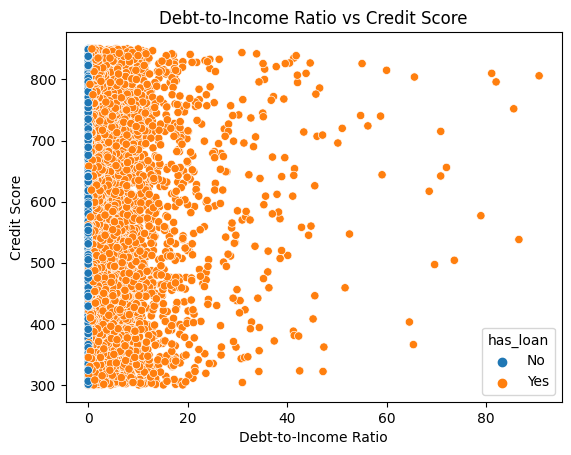

In [15]:
sns.scatterplot(data=df, x='debt_to_income_ratio', y='credit_score', hue='has_loan')
plt.title('Debt-to-Income Ratio vs Credit Score')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Credit Score')
plt.show()


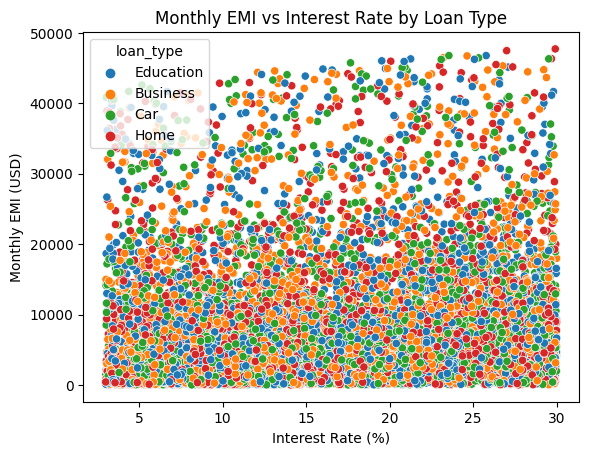

In [16]:
sns.scatterplot(data=df, x='loan_interest_rate_pct', y='monthly_emi_usd', hue='loan_type')
plt.title('Monthly EMI vs Interest Rate by Loan Type')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Monthly EMI (USD)')
plt.show()


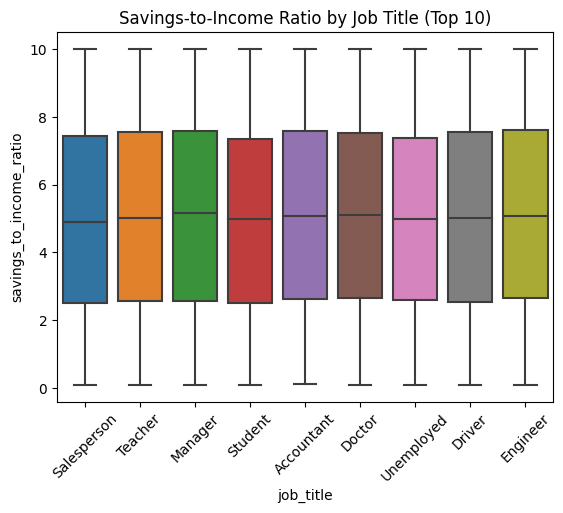

In [17]:
top_jobs = df['job_title'].value_counts().head(10).index
subset = df[df['job_title'].isin(top_jobs)]
sns.boxplot(data=subset, x='job_title', y='savings_to_income_ratio')
plt.xticks(rotation=45)
plt.title('Savings-to-Income Ratio by Job Title (Top 10)')
plt.show()


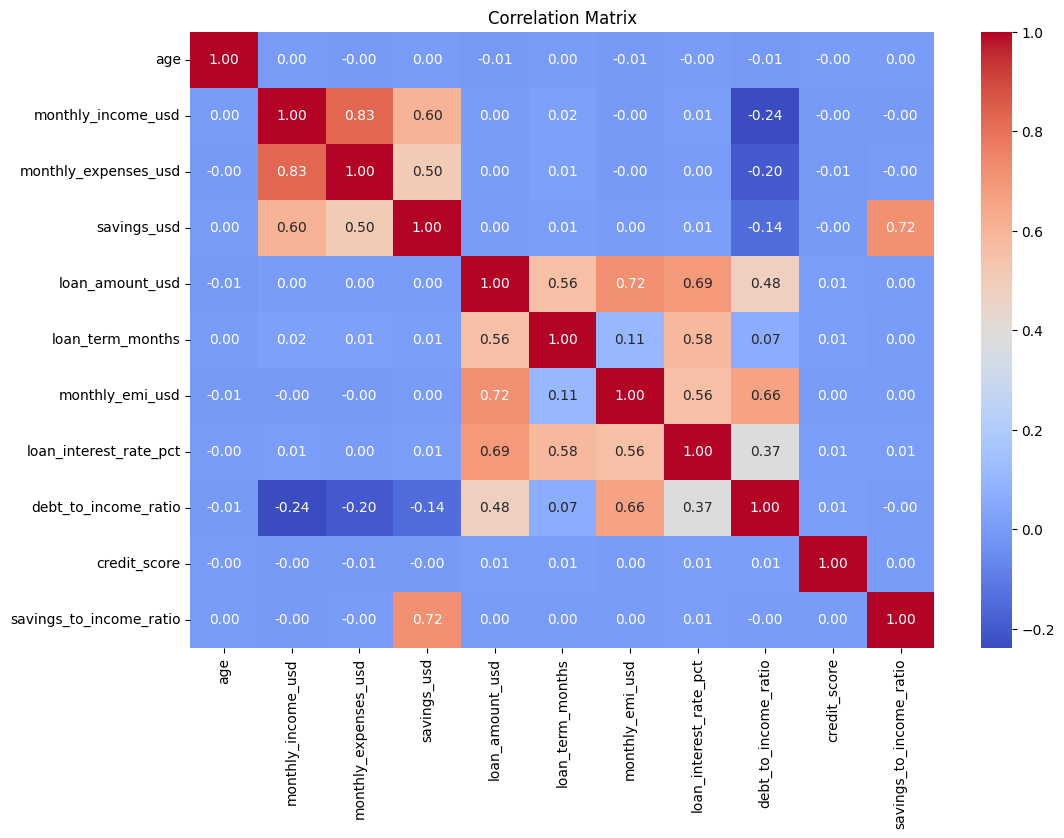

In [18]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


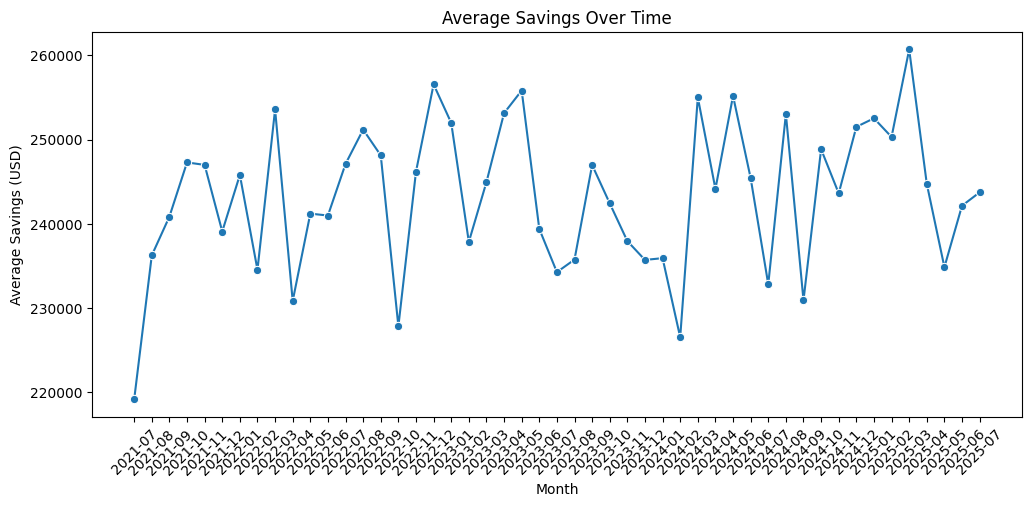

In [19]:
df['record_date'] = pd.to_datetime(df['record_date'])
monthly_trend = df.groupby(df['record_date'].dt.to_period('M')).savings_usd.mean().reset_index()
monthly_trend['record_date'] = monthly_trend['record_date'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_trend, x='record_date', y='savings_usd', marker='o')
plt.xticks(rotation=45)
plt.title('Average Savings Over Time')
plt.xlabel('Month')
plt.ylabel('Average Savings (USD)')
plt.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [21]:
# Drop rows with missing values (optional: you can impute instead)
df = df.dropna()

# Check class distribution of target
print("Original target distribution:")
print(df['has_loan'].value_counts())

# If only one class is present, synthetically add the other class
if df['has_loan'].nunique() == 1:
    print("Only one class present in 'has_loan'. Adding synthetic 'No' class for testing...")
    df_synthetic = df.sample(frac=0.2, random_state=42).copy()
    df_synthetic['has_loan'] = 'No'
    df = pd.concat([df, df_synthetic], ignore_index=True)

# Label encode categorical columns
categorical_cols = ['gender', 'education_level', 'employment_status', 
                    'job_title', 'loan_type', 'region', 'has_loan']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Drop unused columns
df = df.drop(['user_id', 'record_date'], axis=1)

# Define features and target
X = df.drop('has_loan', axis=1)
y = df['has_loan']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

Original target distribution:
has_loan
Yes    12995
Name: count, dtype: int64
Only one class present in 'has_loan'. Adding synthetic 'No' class for testing...


In [22]:
# 8. Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC()
}

# 9. Train and evaluate each model
print("Model Accuracies (%):\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"{name}: {acc:.2f}%")

Model Accuracies (%):

Logistic Regression: 83.33%
Decision Tree: 64.06%
Random Forest: 79.64%
Naive Bayes: 82.75%
K-Nearest Neighbors: 82.78%
Support Vector Machine: 83.33%


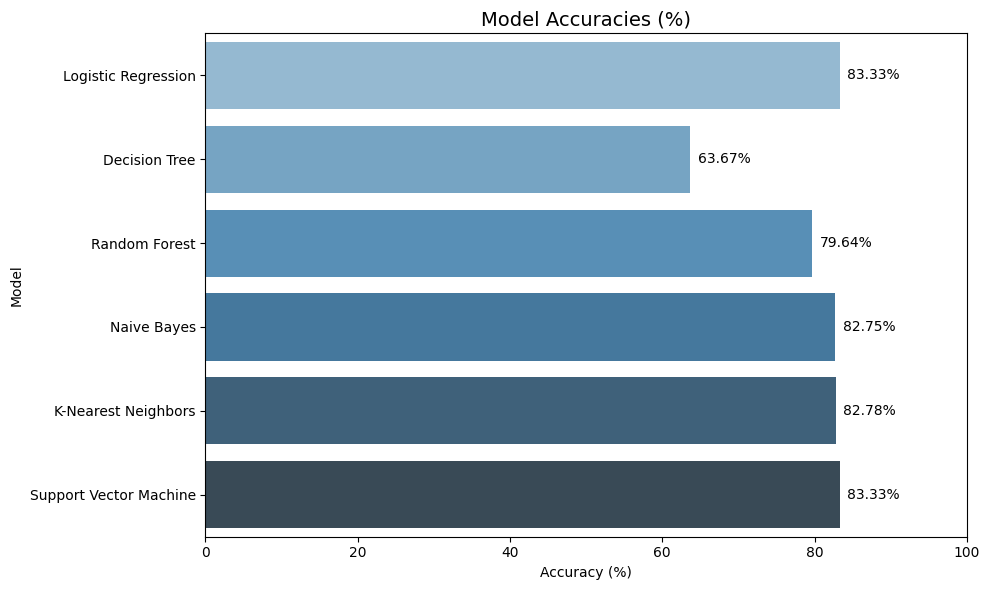

In [23]:
# Accuracy data
model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Naive Bayes",
    "K-Nearest Neighbors",
    "Support Vector Machine"
]
accuracies = [83.33, 63.67, 79.64, 82.75, 82.78, 83.33]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies, y=model_names, palette='Blues_d')

plt.title("Model Accuracies (%)", fontsize=14)
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.xlim(0, 100)

# Show accuracy labels on bars
for i, v in enumerate(accuracies):
    plt.text(v + 1, i, f"{v:.2f}%", color='black', va='center')

plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!